# CdpStC MA2020 GoC + Cav2p1 RI21 SC: NEURON vs BrainCell Cell.run

这个 notebook 用 GoC 的 `CdpStC_MA20_GoC.mod` 搭配 SC 的 `Cav2p1_RI21_SC.mod`，做一个跨来源的 Ca channel + calcium-pool 耦合测试，检查 `ica` 是否能稳定驱动 CDP/STC ion dynamics。


In [1]:
import os
import sys
from pathlib import Path

repo_root = Path('/home/swl/braincell-ion_dyn').resolve()
if str(repo_root) in sys.path:
    sys.path.remove(str(repo_root))
sys.path.insert(0, str(repo_root))

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Cell, Morphology
from braincell.filter import BranchSlice, at
from braincell.mech import Channel, CurrentClamp, CurrentProbe, Ion, MechanismProbe, StateProbe

print('braincell version:', braincell.__version__)
print('braincell import path:', Path(braincell.__file__).resolve())

brainstate.environ.set(precision=64)


braincell version: 0.1.0
braincell import path: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
repo_root = Path(braincell.__file__).resolve().parent.parent
ion_mod = repo_root / 'examples' / 'neuron_compare' / 'Cerebellum_mod' / 'GoC' / 'ion' / 'CdpStC_MA20_GoC.mod'
channel_mod = repo_root / 'examples' / 'neuron_compare' / 'Cerebellum_mod' / 'SC' / 'channel' / 'Cav2p1_RI21_SC.mod'
print('repo_root:', repo_root)
print('ion mod exists:', ion_mod.exists(), ion_mod)
print('channel mod exists:', channel_mod.exists(), channel_mod)

ion_text = ion_mod.read_text()
channel_text = channel_mod.read_text()
print('\nCdpStC INITIAL block preview:')
print(ion_text.split('INITIAL {', 1)[1].split('}', 1)[0][:1600])
print('\nCav2p1 BREAKPOINT block preview:')
print(channel_text.split('BREAKPOINT {', 1)[1].split('}', 1)[0][:900])


repo_root: /home/swl/braincell-ion_dyn
ion mod exists: True /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/GoC/ion/CdpStC_MA20_GoC.mod
channel mod exists: True /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/SC/channel/Cav2p1_RI21_SC.mod

CdpStC INITIAL block preview:

		factors()

		ca = cainull
		mg = mginull
		
		Buff1 = ssBuff1()
		Buff1_ca = ssBuff1ca()

		Buff2 = ssBuff2()
		Buff2_ca = ssBuff2ca()

		BTC = ssBTC()
		BTC_ca = ssBTCca()		

		DMNPE = ssDMNPE()
		DMNPE_ca = ssDMNPEca()

		:CB = ssCB( kdf(), kds())   
	        :CB_f_ca = ssCBfast( kdf(), kds())
       	 	:CB_ca_s = ssCBslow( kdf(), kds())
        	:CB_ca_ca = ssCBca( kdf(), kds())

        	PV = ssPV( kdc(), kdm())
        	PV_ca = ssPVca(kdc(), kdm())
        	PV_mg = ssPVmg(kdc(), kdm())

	:Calmodulin
	CAM0	= CAM_start		
	CAM1C	= 0
	CAM2C	= 0
	CAM1N2C = 0
	CAM1N   = 0
	CAM2N	= 0
	CAM2N1C = 0
	CAM1C1N = 0
	CAM4	= 0
		
  	parea = PI*diam
	parea2 = PI*(diam-0.2)
	ica = 0
	ica_pmp 

In [3]:
dt_ms = 0.05
duration_ms = 40.0
steps = int(duration_ms / dt_ms)
times_ms = np.arange(steps + 1) * dt_ms

temperature_celsius = 25.0
v_init_mV = -60.0
diam_um = 20.0
length_um = 20.0

stim_delay_ms = 5.0
stim_dur_ms = 20.0
stim_amp_nA = 0.5

pcabar_cm_s = 0.00022

cam_fields = [
    'CAM0',
    'CAM1C',
    'CAM2C',
    'CAM1N2C',
    'CAM1N',
    'CAM2N',
    'CAM2N1C',
    'CAM1C1N',
    'CAM4',
]

tracked_fields = ['v', 'Ci', 'ica', 'm', 'pump', 'pumpca'] + cam_fields
print({
    'dt_ms': dt_ms,
    'duration_ms': duration_ms,
    'temperature_celsius': temperature_celsius,
    'v_init_mV': v_init_mV,
    'length_um': length_um,
    'diam_um': diam_um,
    'stim_delay_ms': stim_delay_ms,
    'stim_dur_ms': stim_dur_ms,
    'stim_amp_nA': stim_amp_nA,
    'pcabar_cm_s': pcabar_cm_s,
    'tracked_fields': tracked_fields,
})


{'dt_ms': 0.05, 'duration_ms': 40.0, 'temperature_celsius': 25.0, 'v_init_mV': -60.0, 'length_um': 20.0, 'diam_um': 20.0, 'stim_delay_ms': 5.0, 'stim_dur_ms': 20.0, 'stim_amp_nA': 0.5, 'pcabar_cm_s': 0.00022, 'tracked_fields': ['v', 'Ci', 'ica', 'm', 'pump', 'pumpca', 'CAM0', 'CAM1C', 'CAM2C', 'CAM1N2C', 'CAM1N', 'CAM2N', 'CAM2N1C', 'CAM1C1N', 'CAM4']}


In [4]:
from neuron import h, load_mechanisms
import shutil
import subprocess
import tempfile

compile_cmd = [
    'nrnivmodl',
    str(ion_mod),
    str(channel_mod),
]
compile_hint = (
    'Compile a mixed GoC-ion + SC-channel mechanism directory with:\n'
    'tmpdir=$(mktemp -d)\n'
    'cd "$tmpdir"\n'
    'CPP=/usr/bin/cpp CC=/usr/bin/cc CXX=/usr/bin/c++ nrnivmodl ' + str(ion_mod) + ' ' + str(channel_mod) + '\n'
    'If this Python/Jupyter process already loaded an older libnrnmech.so, restart the kernel first.'
)

# Optional override: point this at an already-compiled mixed mechanism directory.
compiled_mod_dir = None
if compiled_mod_dir is None:
    auto_tmpdir = Path(tempfile.mkdtemp(prefix='cdpstc_cav2p1_'))
    cpp = shutil.which('cpp') or '/usr/bin/cpp'
    cc = shutil.which('cc') or '/usr/bin/cc'
    cxx = shutil.which('c++') or '/usr/bin/c++'
    print('Auto-compiling mixed NEURON mods into:', auto_tmpdir)
    proc = subprocess.run(
        compile_cmd,
        cwd=auto_tmpdir,
        env={**os.environ, 'CPP': cpp, 'CC': cc, 'CXX': cxx},
        capture_output=True,
        text=True,
    )
    print(proc.stdout)
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError(compile_hint)
    compiled_mod_dir = auto_tmpdir
else:
    compiled_mod_dir = Path(compiled_mod_dir)
print('compiled_mod_dir:', compiled_mod_dir)

if not compiled_mod_dir.exists():
    raise RuntimeError(compile_hint)
if not load_mechanisms(str(compiled_mod_dir.resolve())):
    raise RuntimeError(compile_hint)
h.load_file('stdrun.hoc')

sec = h.Section(name='soma')
sec.L = length_um
sec.diam = diam_um
sec.nseg = 1
seg = sec(0.5)
try:
    sec.insert('CdpStC_MA20_GoC')
    sec.insert('Cav2p1_RI21_SC')
except ValueError as exc:
    raise RuntimeError(compile_hint) from exc

ion_mech = seg.CdpStC_MA20_GoC
channel_mech = seg.Cav2p1_RI21_SC
channel_mech.pcabar = pcabar_cm_s

stim = h.IClamp(seg)
stim.delay = stim_delay_ms
stim.dur = stim_dur_ms
stim.amp = stim_amp_nA

h.celsius = temperature_celsius
h.dt = dt_ms
h.steps_per_ms = 1.0 / h.dt
h.tstop = duration_ms
h.v_init = v_init_mV

t_vec = h.Vector().record(h._ref_t)
v_vec = h.Vector().record(seg._ref_v)
cai_vec = h.Vector().record(seg._ref_cai)
ica_vec = h.Vector().record(seg._ref_ica)
pump_vec = h.Vector().record(ion_mech._ref_pump)
pumpca_vec = h.Vector().record(ion_mech._ref_pumpca)
m_vec = h.Vector().record(channel_mech._ref_m)
cam_vectors = {name: h.Vector().record(getattr(ion_mech, f'_ref_{name}')) for name in cam_fields}

h.finitialize(h.v_init)
h.frecord_init()
h.continuerun(h.tstop)

neuron_t_ms = np.asarray(t_vec)
neuron_data = {
    'v': np.asarray(v_vec),
    'Ci': np.asarray(cai_vec),
    'ica': -np.asarray(ica_vec),
    'pump': np.asarray(pump_vec),
    'pumpca': np.asarray(pumpca_vec),
    'm': np.asarray(m_vec),
}
for name, vec in cam_vectors.items():
    neuron_data[name] = np.asarray(vec)
neuron_total = neuron_data['pump'] + neuron_data['pumpca']

print('max |-NEURON ica|:', float(np.max(np.abs(neuron_data['ica']))))
print('NEURON start/end v:', float(neuron_data['v'][0]), float(neuron_data['v'][-1]))
print('NEURON start/end cai:', float(neuron_data['Ci'][0]), float(neuron_data['Ci'][-1]))
print('NEURON start/end Cav2p1 m:', float(neuron_data['m'][0]), float(neuron_data['m'][-1]))
print('NEURON start/end pump:', float(neuron_data['pump'][0]), float(neuron_data['pump'][-1]))
print('NEURON start/end pumpca:', float(neuron_data['pumpca'][0]), float(neuron_data['pumpca'][-1]))
print('NEURON max pump conserve drift:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
for name in cam_fields:
    arr = neuron_data[name]
    print(f'NEURON {name} start/end:', float(arr[0]), float(arr[-1]))


Auto-compiling mixed NEURON mods into: /tmp/cdpstc_cav2p1_hmc7n5af


--No graphics will be displayed.


/tmp/cdpstc_cav2p1_hmc7n5af
Mod files: "/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/GoC/ion//home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/GoC/ion/CdpStC_MA20_GoC.mod" "/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/SC/channel//home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/SC/channel/Cav2p1_RI21_SC.mod"

Creating 'x86_64' directory for .o files.

 -> Compiling mod_func.cpp
 -> NMODL /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/GoC/ion/CdpStC_MA20_GoC.mod
 -> NMODL /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/SC/channel/Cav2p1_RI21_SC.mod
 -> Compiling Cav2p1_RI21_SC.c
 -> Compiling CdpStC_MA20_GoC.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created x86_64/special

compiled_mod_dir: /tmp/cdpstc_cav2p1_hmc7n5af
max |-NEURON ica|: 0.033277606738892046
NEURON start/end v: -60.0 757.955665459749

In [5]:
dt = dt_ms * u.ms
duration = duration_ms * u.ms

soma = Branch.from_lengths(lengths=[length_um] * u.um, radii=[diam_um / 2.0, diam_um / 2.0] * u.um, type='soma')
morpho = Morphology.from_root(soma, name='soma')
region = BranchSlice(branch_index=0, prox=0.0, dist=1.0)

cell = Cell(morpho, solver='staggered', V_init=v_init_mV * u.mV)
cell.paint(
    region,
    Ion(
        'CdpStC_MA2020_GoC',
        name='ca_stc',
        temp=u.celsius2kelvin(temperature_celsius),
    ),
)
cell.paint(
    region,
    Channel(
        'Cav2p1_RI2021_SC',
        ion_name='ca_stc',
        g_max=pcabar_cm_s * (u.cm / u.second),
        temp=u.celsius2kelvin(temperature_celsius),
    ),
)
cell.place(
    at('soma', 0.5),
    CurrentClamp(delay=stim_delay_ms * u.ms, durations=stim_dur_ms * u.ms, amplitudes=stim_amp_nA * u.nA),
    StateProbe(),
    MechanismProbe(mechanism='ca_stc', field='Ci'),
    MechanismProbe(mechanism='ca_stc', field='pump'),
    MechanismProbe(mechanism='ca_stc', field='pumpca'),
    MechanismProbe(mechanism='ca_stc', field='CAM0'),
    MechanismProbe(mechanism='ca_stc', field='CAM1C'),
    MechanismProbe(mechanism='ca_stc', field='CAM2C'),
    MechanismProbe(mechanism='ca_stc', field='CAM1N2C'),
    MechanismProbe(mechanism='ca_stc', field='CAM1N'),
    MechanismProbe(mechanism='ca_stc', field='CAM2N'),
    MechanismProbe(mechanism='ca_stc', field='CAM2N1C'),
    MechanismProbe(mechanism='ca_stc', field='CAM1C1N'),
    MechanismProbe(mechanism='ca_stc', field='CAM4'),
    MechanismProbe(mechanism='ca_stc', field='vrat'),
    MechanismProbe(mechanism='ca_stc', field='parea'),
    MechanismProbe(mechanism='ca_stc', field='dsq'),
    MechanismProbe(mechanism='ca_stc', field='dsqvol'),
    MechanismProbe(mechanism='Cav2p1_RI2021_SC', field='m'),
    CurrentProbe(ion='ca_stc', mechanism='Cav2p1_RI2021_SC'),
)

with brainstate.environ.context(precision=64):
    cell.init_state()
    cell.reset_state()
    print('initial probe v (mV):', float(np.asarray(cell.sample_probe('soma(0.5)_v').to_decimal(u.mV)).reshape(-1)[0]))
    print('initial probe Ci (mM):', float(np.asarray(cell.sample_probe('soma(0.5)_ca_stc_Ci').to_decimal(u.mM)).reshape(-1)[0]))
    print('initial probe Cav2p1 m:', float(np.asarray(cell.sample_probe('soma(0.5)_Cav2p1_RI2021_SC_m')).reshape(-1)[0]))
    run_result = cell.run(dt=dt, duration=duration)

cell_data = {
    'v': np.asarray(run_result.traces['soma(0.5)_v'].to_decimal(u.mV)),
    'Ci': np.asarray(run_result.traces['soma(0.5)_ca_stc_Ci'].to_decimal(u.mM)),
    'pump': np.asarray(run_result.traces['soma(0.5)_ca_stc_pump'].to_decimal(u.mol / u.cm ** 2)),
    'pumpca': np.asarray(run_result.traces['soma(0.5)_ca_stc_pumpca'].to_decimal(u.mol / u.cm ** 2)),
    'm': np.asarray(run_result.traces['soma(0.5)_Cav2p1_RI2021_SC_m']),
    'ica': np.asarray(run_result.traces['soma(0.5)_Cav2p1_RI2021_SC_current'].to_decimal(u.mA / (u.cm ** 2))),
}
for name in cam_fields:
    cell_data[name] = np.asarray(run_result.traces[f'soma(0.5)_ca_stc_{name}'].to_decimal(u.mM))
cell_geometry = {
    'vrat': np.asarray(run_result.traces['soma(0.5)_ca_stc_vrat']),
    'parea': np.asarray(run_result.traces['soma(0.5)_ca_stc_parea'].to_decimal(u.um)),
    'dsq': np.asarray(run_result.traces['soma(0.5)_ca_stc_dsq'].to_decimal(u.um ** 2)),
    'dsqvol': np.asarray(run_result.traces['soma(0.5)_ca_stc_dsqvol'].to_decimal(u.um ** 2)),
}
cell_total = cell_data['pump'] + cell_data['pumpca']

print('Cell.run max |current|:', float(np.max(np.abs(cell_data['ica']))))
print('Cell.run start/end v:', float(cell_data['v'][0]), float(cell_data['v'][-1]))
print('Cell.run start/end Ci:', float(cell_data['Ci'][0]), float(cell_data['Ci'][-1]))
print('Cell.run start/end Cav2p1 m:', float(cell_data['m'][0]), float(cell_data['m'][-1]))
print('Cell.run start/end pump:', float(cell_data['pump'][0]), float(cell_data['pump'][-1]))
print('Cell.run start/end pumpca:', float(cell_data['pumpca'][0]), float(cell_data['pumpca'][-1]))
print('Cell.run max pump conserve drift:', float(np.max(np.abs(cell_total - cell_total[0]))))
for name in cam_fields:
    arr = cell_data[name]
    print(f'Cell.run {name} start/end:', float(arr[0]), float(arr[-1]))
for name, arr in cell_geometry.items():
    print(f'Cell.run {name} first/last:', float(arr[0]), float(arr[-1]))
for name, arr in cell_data.items():
    assert np.isfinite(arr).all(), f'{name} contains non-finite values'


initial probe v (mV): -60.0
initial probe Ci (mM): 4.5e-05
initial probe Cav2p1 m: 0.025996755935181207
Cell.run max |current|: 0.03201607844547077
Cell.run start/end v: -59.999648334731766 755.2111343837662
Cell.run start/end Ci: 4.3378355691365213e-05 4.377399087299507e-05
Cell.run start/end Cav2p1 m: 0.02599684764618391 0.9999999999999998
Cell.run start/end pump: 9.99999993493276e-10 9.999938267973224e-10
Cell.run start/end pumpca: 6.506724016195698e-18 6.173202677599572e-15
Cell.run max pump conserve drift: 0.0
Cell.run CAM0 start/end: 0.029930822014009345 0.029736342556295616
Cell.run CAM1C start/end: 1.0150011501876856e-05 0.000175737705589493
Cell.run CAM2C start/end: 1.0395762231557453e-08 1.2491741565297097e-05
Cell.run CAM1N2C start/end: 2.640407449818054e-11 3.116838110288467e-08
Cell.run CAM1N start/end: 5.866251947736756e-05 7.419571182971552e-05
Cell.run CAM2N start/end: 3.2998837896799523e-07 7.578328183463217e-07
Cell.run CAM2N1C start/end: 1.9154622753833666e-10 4.4786

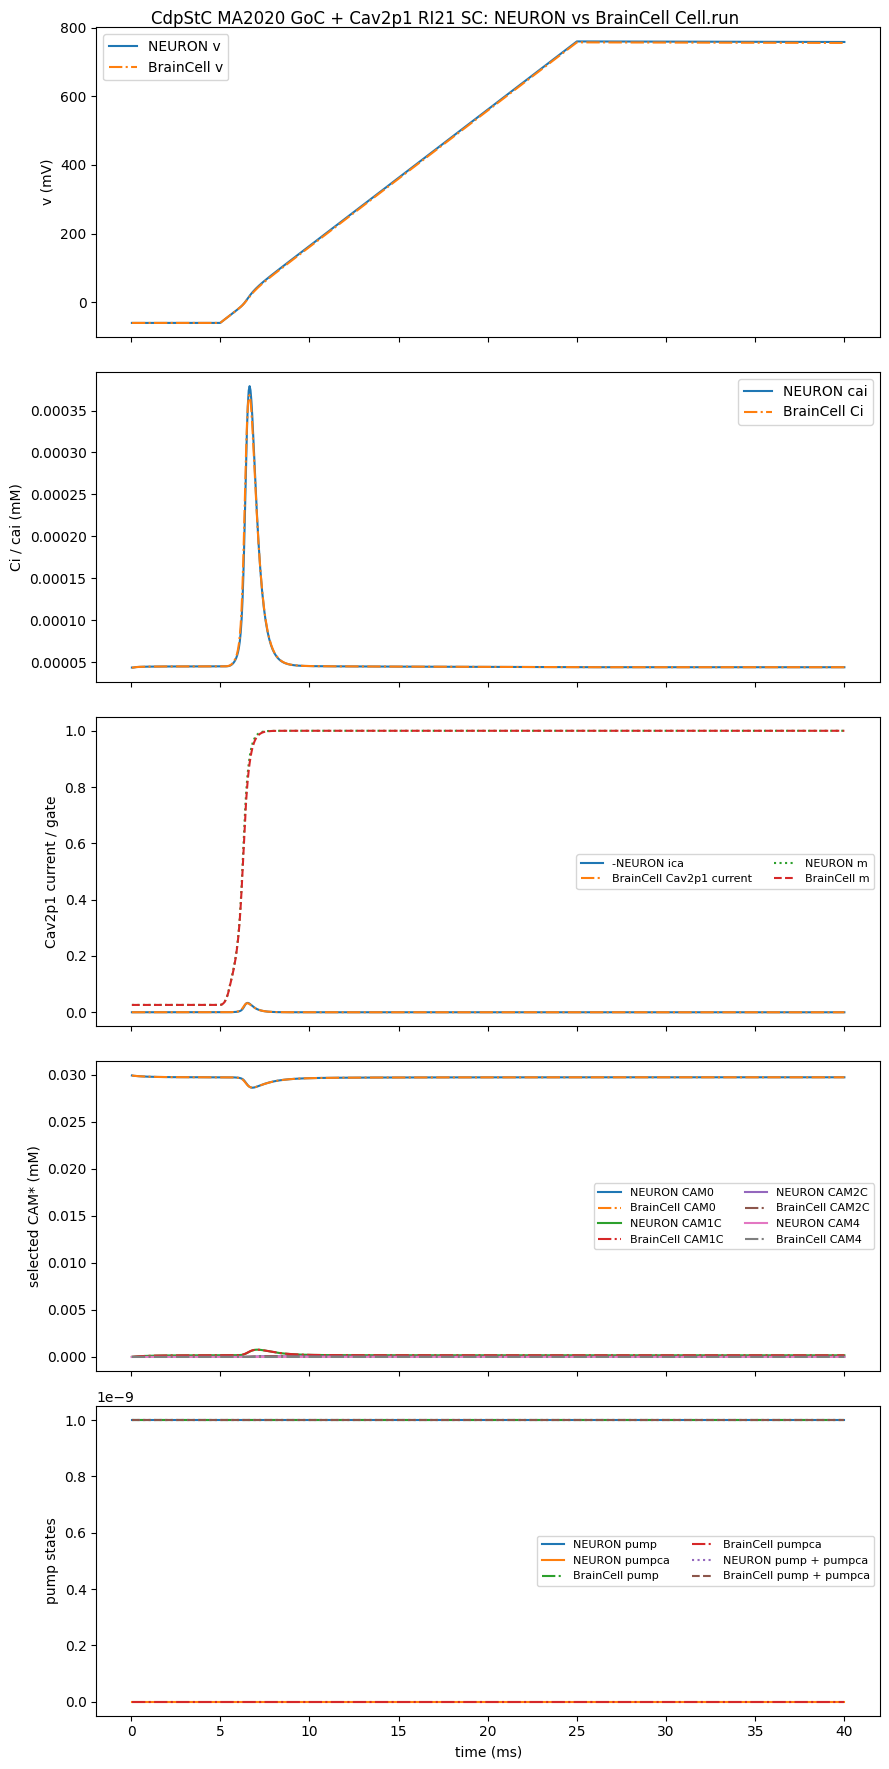

Per-field Cell.run vs NEURON error summary:
v {'mae': 2.3063967605162174, 'rmse': 2.5145931668249633, 'max_abs': 2.8137766302706453}
Ci {'mae': 3.326287251286018e-07, 'rmse': 1.9684588503144757e-06, 'max_abs': 2.271848887916482e-05}
ica {'mae': 4.016672200030757e-05, 'rmse': 0.0002659550688986914, 'max_abs': 0.003393383356412604}
m {'mae': 0.0005447285248281018, 'rmse': 0.003028899693081635, 'max_abs': 0.027681250185404127}
pump {'mae': 1.0963697423531818e-17, 'rmse': 1.1929939164669535e-17, 'max_abs': 2.2450012283343886e-17}
pumpca {'mae': 1.0963697361723117e-17, 'rmse': 1.1929939109066686e-17, 'max_abs': 2.2450012102910295e-17}
CAM0 {'mae': 9.71393771084161e-07, 'rmse': 5.107370338376806e-06, 'max_abs': 6.123893516991191e-05}
CAM1C {'mae': 4.538012714126645e-07, 'rmse': 2.363805415917294e-06, 'max_abs': 2.5051009031287655e-05}
CAM2C {'mae': 1.1437725982734407e-07, 'rmse': 2.55898623652871e-07, 'max_abs': 1.5812998931523176e-06}
CAM1N2C {'mae': 7.466047226875e-10, 'rmse': 2.8652321432

In [6]:
compare_t_ms = neuron_t_ms[1:]

def summarize_error(y, ref):
    y = np.asarray(y)
    ref = np.asarray(ref)
    n = min(len(y), len(ref))
    diff = y[:n] - ref[:n]
    return {
        'mae': float(np.mean(np.abs(diff))),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'max_abs': float(np.max(np.abs(diff))),
    }

error_summary = {}
for name in tracked_fields:
    neuron_cmp = neuron_data[name][1:]
    cell_cmp = cell_data[name]
    error_summary[name] = summarize_error(cell_cmp, neuron_cmp[:len(cell_cmp)])

fig, axes = plt.subplots(5, 1, figsize=(9, 18), sharex=True)

axes[0].plot(compare_t_ms, neuron_data['v'][1:], label='NEURON v')
axes[0].plot(compare_t_ms[:len(cell_data['v'])], cell_data['v'], '-.', label='BrainCell v')
axes[0].set_ylabel('v (mV)')
axes[0].legend()

axes[1].plot(compare_t_ms, neuron_data['Ci'][1:], label='NEURON cai')
axes[1].plot(compare_t_ms[:len(cell_data['Ci'])], cell_data['Ci'], '-.', label='BrainCell Ci')
axes[1].set_ylabel('Ci / cai (mM)')
axes[1].legend()

axes[2].plot(compare_t_ms, neuron_data['ica'][1:], label='-NEURON ica')
axes[2].plot(compare_t_ms[:len(cell_data['ica'])], cell_data['ica'], '-.', label='BrainCell Cav2p1 current')
axes[2].plot(compare_t_ms, neuron_data['m'][1:], ':', label='NEURON m')
axes[2].plot(compare_t_ms[:len(cell_data['m'])], cell_data['m'], '--', label='BrainCell m')
axes[2].set_ylabel('Cav2p1 current / gate')
axes[2].legend(ncol=2, fontsize=8)

for name in ['CAM0', 'CAM1C', 'CAM2C', 'CAM4']:
    axes[3].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[3].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[3].set_ylabel('selected CAM* (mM)')
axes[3].legend(ncol=2, fontsize=8)

axes[4].plot(compare_t_ms, neuron_data['pump'][1:], label='NEURON pump')
axes[4].plot(compare_t_ms, neuron_data['pumpca'][1:], label='NEURON pumpca')
axes[4].plot(compare_t_ms[:len(cell_data['pump'])], cell_data['pump'], '-.', label='BrainCell pump')
axes[4].plot(compare_t_ms[:len(cell_data['pumpca'])], cell_data['pumpca'], '-.', label='BrainCell pumpca')
axes[4].plot(compare_t_ms, neuron_total[1:], ':', label='NEURON pump + pumpca')
axes[4].plot(compare_t_ms[:len(cell_total)], cell_total, '--', label='BrainCell pump + pumpca')
axes[4].set_xlabel('time (ms)')
axes[4].set_ylabel('pump states')
axes[4].legend(ncol=2, fontsize=8)

plt.suptitle('CdpStC MA2020 GoC + Cav2p1 RI21 SC: NEURON vs BrainCell Cell.run')
plt.tight_layout()
plt.show()

print('Per-field Cell.run vs NEURON error summary:')
for name in tracked_fields:
    print(name, error_summary[name])

print('\nPump conserve drift:')
print('  NEURON:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
print('  BrainCell Cell.run:', float(np.max(np.abs(cell_total - cell_total[0]))))

print('\nCa current nonzero check:')
print('  max |-NEURON ica|:', float(np.max(np.abs(neuron_data['ica']))))
print('  max |BrainCell current|:', float(np.max(np.abs(cell_data['ica']))))

cam_extra = ['CAM1N2C', 'CAM1N', 'CAM2N', 'CAM2N1C', 'CAM1C1N']
print('\nExtra CAM* end-state comparison:')
for name in cam_extra:
    print(
        name,
        {
            'NEURON_end': float(neuron_data[name][-1]),
            'cell_end': float(cell_data[name][-1]),
        },
    )
